If you want tool calling, you MUST:

Bind tools to LLM

Detect tool calls

Execute tool

Loop back to LLM with tool result

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import render_text_description

# 1️⃣ Define Tool
@tool
def multiply(a: int, b: int):
    """Multiply two numbers"""
    return a * b

tools = [multiply]

# 2️⃣ Bind tools to LLM

# 3️⃣ Define State
class GraphState(TypedDict):
    messages: list

# 4️⃣ Agent Node
def agent_node(state: GraphState):
    response = llm.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}

# 5️⃣ Tool Node
def tool_node(state: GraphState):
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]

    result = multiply.invoke(tool_call["args"])

    tool_message = ToolMessage(
        content=str(result),
        tool_call_id=tool_call["id"],
    )

    return {"messages": state["messages"] + [tool_message]}

# 6️⃣ Conditional Logic
def should_continue(state: GraphState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool"
    return "end"

# 7️⃣ Build Graph
builder = StateGraph(GraphState)

builder.add_node("agent", agent_node)
builder.add_node("tool", tool_node)

builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tool": "tool",
        "end": END
    }
)

builder.add_edge("tool", "agent")

builder.set_entry_point("agent")

graph = builder.compile()

# 8️⃣ Run
if __name__ == "__main__":
    result = graph.invoke({
        "messages": [HumanMessage(content="What is 7 multiplied by 6?")]
    })

    print(result["messages"][-1].content)

7 * 6 = 42.


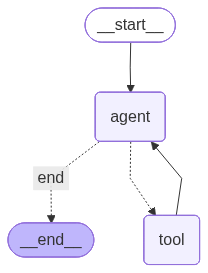

In [3]:
graph 

In [6]:
result = graph.invoke({
        "messages": [HumanMessage(content="What is rag pipline?")]
    })

print(result["messages"][-1].content)

The RAG (Red, Amber, Green) pipeline is a project management framework used to track the progress and status of multiple projects or tasks within an organization. It's a simple, visual tool that helps teams prioritize, manage, and report on their work.

Here's a breakdown of the RAG pipeline:

1. **Red**: Projects or tasks that are at risk, behind schedule, or experiencing significant issues. These items require immediate attention and intervention to get them back on track.
2. **Amber** (or Yellow): Projects or tasks that are proceeding with some caution or concerns. These items may be experiencing minor issues or delays, but they are still on track to meet their deadlines.
3. **Green**: Projects or tasks that are on track, proceeding as planned, and meeting their milestones. These items are considered healthy and require minimal attention.

The RAG pipeline is often used in conjunction with other project management methodologies, such as Agile or Waterfall. It provides a high-level o

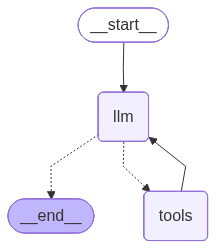

In [10]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode

class CalcState(TypedDict):
    a: int
    b: int
    result: int


@tool
def multiply(a: int, b: int) -> int:
    "multiply two numbers"
    return a * b
@tool
def addition(a: int, b: int) -> int:
    "addition two numbers"
    return a+b

#llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools([multiply, addition])

def llm_node(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

tool_node = ToolNode([multiply,addition])

builder = StateGraph(MessagesState)

builder.add_node("llm", llm_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "llm")

def route_tools(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

builder.add_conditional_edges(
    "llm",
    route_tools,
    {"tools": "tools", END: END},
)

builder.add_edge("tools", "llm")

graph = builder.compile()

graph

In [11]:
result = graph.invoke({
    "messages": [HumanMessage(content="What is 5 + 3?")]
})

print(result)

{'messages': [HumanMessage(content='What is 5 + 3?', additional_kwargs={}, response_metadata={}, id='3afd8c6e-5fd7-4b51-8f70-09fe7e1b6efd'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fyytb37p0', 'function': {'arguments': '{"a":5,"b":3}', 'name': 'addition'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 275, 'total_tokens': 294, 'completion_time': 0.047574015, 'completion_tokens_details': None, 'prompt_time': 0.034113543, 'prompt_tokens_details': None, 'queue_time': 0.04828229, 'total_time': 0.081687558}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cae6b-4a1a-7702-bc26-1d0d0bd407be-0', tool_calls=[{'name': 'addition', 'args': {'a': 5, 'b': 3}, 'id': 'fyytb37p0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 275, 'output_tokens